In [1]:
import os
import numpy as np
import datetime
import geopandas as gp
import pandas as pd

In [2]:
gdf = gp.read_file("../shape/sierra_catchments.shp")

In [3]:
results_df = []
param_df = []

In [4]:
for stid in list(gdf['stid'])[:]:
    
    akm2 = float(gdf[gdf['stid'] == stid].area_km2)
    elev = float(gdf[gdf['stid'] == stid].elev_ft)
    
    # Read rainfall and snowmelt data
    smlt_fn_1d = "../data/Watersheds/smlt/{}_smlt.npy".format(stid)
    prcp_fn_1d = "../data/Watersheds/prcp/{}_prcp.npy".format(stid)
    
    # Read runoff
    bf = pd.read_csv("../data/baseflow_sep/baseflow_mm.csv")
    bf['date'] = pd.to_datetime(bf['date'])
    bf.set_index("date", inplace = True)    
    sr = pd.read_csv("../data/baseflow_sep/surface_runoff_mm.csv") 
    sr['date'] = pd.to_datetime(sr['date'])
    sr.set_index("date", inplace = True)   

    # Load files as np arrays
    smlt = np.load(smlt_fn_1d)
    smlt = smlt*1e2 # apply scaling factor 
    prcp = np.load(prcp_fn_1d)

    # filter the runoff data to select watershed, convert to mm
    sr_df = pd.DataFrame(sr[stid].interpolate(how = 'linear'))[:-1] / float(akm2) * 1e-9 * 1e6 * 0.0283168
    bf_df = pd.DataFrame(bf[stid].interpolate(how = 'linear'))[:-1] / float(akm2) * 1e-9 * 1e6 * 0.0283168

    smlt_mean = [np.nanmean(smlt[:,:,x]) for x in range(0,smlt.shape[2])]
    prcp_mean = [np.nanmean(prcp[:,:,x]) for x in range(0,prcp.shape[2])]

    ann_pmean = np.nanmean(prcp_mean) * 365
    ann_smean = np.nanmean(smlt_mean) * 365
    ann_bf_mean = float((bf_df.mean().values * 86400)) * 365
    
    pdf = pd.DataFrame([stid, ann_pmean, ann_smean, ann_bf_mean]).T
    pdf.columns = ['id', 'Rainfall (mm)' , 'Snowmelt (mm)', "Baseflow (mm)"]
    param_df.append(pdf)

/var/folders/py/9t078qzs52x65tkpvg23_4mc0000gn/T/ipykernel_57372/4093631902.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  akm2 = float(gdf[gdf['stid'] == stid].area_km2)
/var/folders/py/9t078qzs52x65tkpvg23_4mc0000gn/T/ipykernel_57372/4093631902.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  elev = float(gdf[gdf['stid'] == stid].elev_ft)
/var/folders/py/9t078qzs52x65tkpvg23_4mc0000gn/T/ipykernel_57372/4093631902.py:27: RuntimeWarning: Mean of empty slice
  smlt_mean = [np.nanmean(smlt[:,:,x]) for x in range(0,smlt.shape[2])]
/var/folders/py/9t078qzs52x65tkpvg23_4mc0000gn/T/ipykernel_57372/4093631902.py:28: RuntimeWarning: Mean of empty slice
  prcp_mean = [np.nanmean(prcp[:,:,x]) for x in range(0,prcp.shape[2])]
/var/folders/py/9t078qzs52x65tkpvg23_4mc0000gn/T/ipykernel_57372/4093

In [5]:
pd.concat(param_df)

,id,Rainfall (mm),Snowmelt (mm),Baseflow (mm)
0,SJF,426.798445,292.367259,206.225574
0,TLG,545.593996,380.859265,215.431409
0,ISB,244.389362,253.321744,80.320773
0,NAT,850.41025,374.014674,252.820745
0,MHB,818.577124,306.529095,117.550204
0,NML,603.041234,379.836223,192.056863
0,ORO,712.339513,308.634265,221.460364
0,TRM,527.97536,266.11696,159.401784
0,MKM,712.381746,334.126111,239.486352
0,SCC,504.78822,243.122555,65.638448


In [6]:
# Write out table 1 

t1df = pd.merge(gdf,pd.concat(param_df), left_on = 'stid', right_on = 'id')

In [7]:
# Write table 1 
t1df.drop(['stid','agency','outlet_id','geometry'], axis =1).to_csv("../data/Table1.csv")


In [8]:
# Figure 4

In [9]:
bf = pd.read_csv("../data/baseflow_sep/baseflow_mm.csv")
bf['date'] = pd.to_datetime(bf['date'])
bf.set_index('date', inplace=True)
sh_bf = bf['SHA']

In [10]:
sr = pd.read_csv("../data/baseflow_sep/surface_runoff_mm.csv")
sr['date'] = pd.to_datetime(sr['date'])
sr.set_index('date', inplace=True)
sh_sr = sr['SHA'] + sh_bf

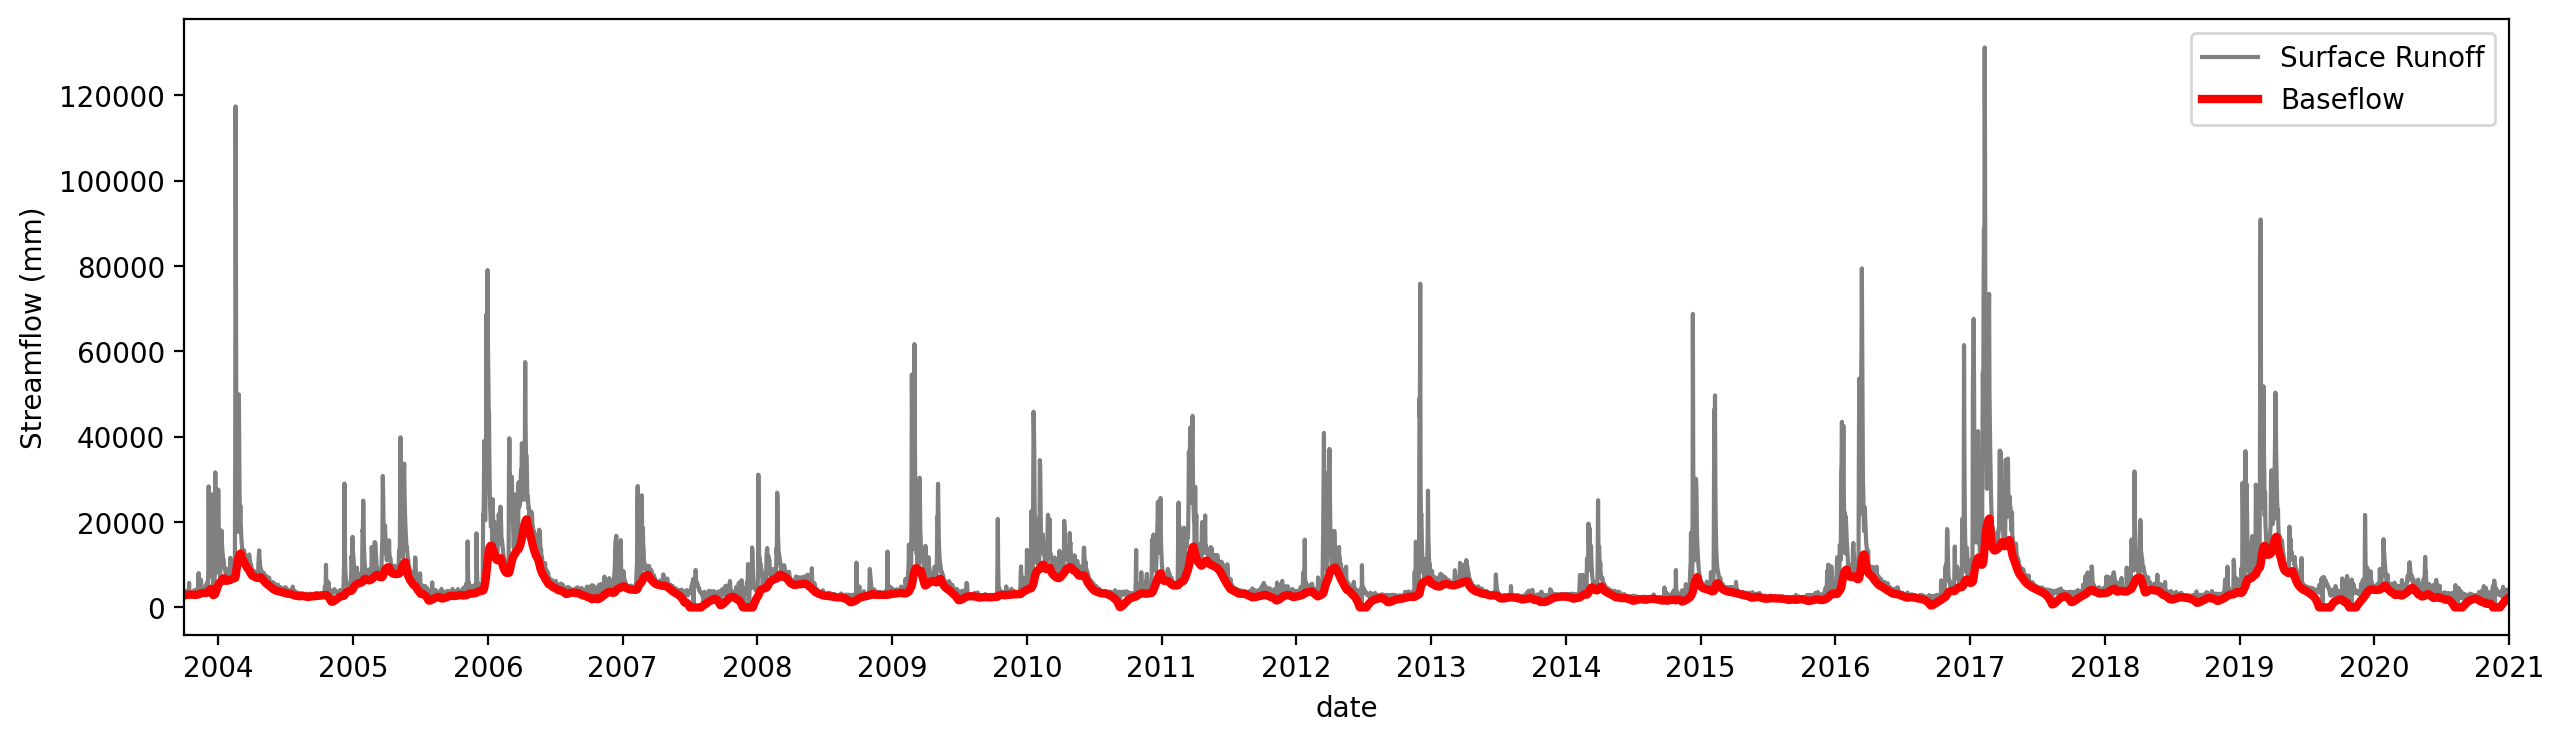

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize = (15,4), dpi=200)
sh_sr.plot(ax = ax, c = 'gray', label = 'Surface Runoff')
sh_bf.plot(ax = ax, c = 'red', linewidth = 3, label = 'Baseflow')
# Set the major locator to place ticks at the start of each year
ax.xaxis.set_major_locator(mdates.YearLocator())

# Set the major formatter to display only the year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlim([datetime.date(2003, 10, 1), datetime.date(2021, 1, 1)])

plt.legend()
plt.ylabel("Streamflow (mm)")
plt.savefig("../results/fig4.png")